In [47]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_friedman1 # for nonlinear relationships
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [48]:
X, y = make_friedman1(n_samples=1000, n_features=10, noise=0.1, random_state=5) # last 5 features do not affect output

In [49]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=5)

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(n_estimators=50, random_state=5,)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"test mse: {mean_squared_error(y_test, y_pred):.4f}")

test mse: 0.1398


In [52]:
def predict_func(df: pd.DataFrame):
    return np.atleast_1d(rf.predict(df.values).squeeze())

In [53]:
import sys
sys.path.insert(0, "../sage")
from sage_base import Sage_Explainer

In [54]:
feature_names = [f"x{i}" for i in range(10)]
X_train_df = pd.DataFrame(X_train, columns=feature_names)

In [55]:
sage = Sage_Explainer(predict_func)
sage.fit(X_train_df, perturbation_strength=0.2)

In [62]:
def get_cfd_sensitivities(instance: dict, epsilon=0.01):
    sensitivities = {}
    instance_df = pd.DataFrame([instance])
    base_pred = predict_func(instance_df)[0]

    for feature in feature_names:
        fwd = instance.copy()
        bwd = instance.copy()
        fwd[feature] += epsilon
        bwd[feature] -= epsilon
        fwd_pred = predict_func(pd.DataFrame([fwd]))[0]
        bwd_pred = predict_func(pd.DataFrame([bwd]))[0]
        sensitivities[feature] = (fwd_pred - bwd_pred) / (2 * epsilon)

    return sensitivities

In [63]:
n_samples = 100
results = []

for i in range(n_samples):
    instance = dict(zip(feature_names, X_test[i]))
    sage_sens = sage.explain(instance)
    cfd_sens = get_cfd_sensitivities(instance)

    for feature in feature_names:
        results.append({
            "feature": feature,
            "sage": sage_sens[feature],
            "cfd": cfd_sens[feature]
        })

results_df = pd.DataFrame(results)

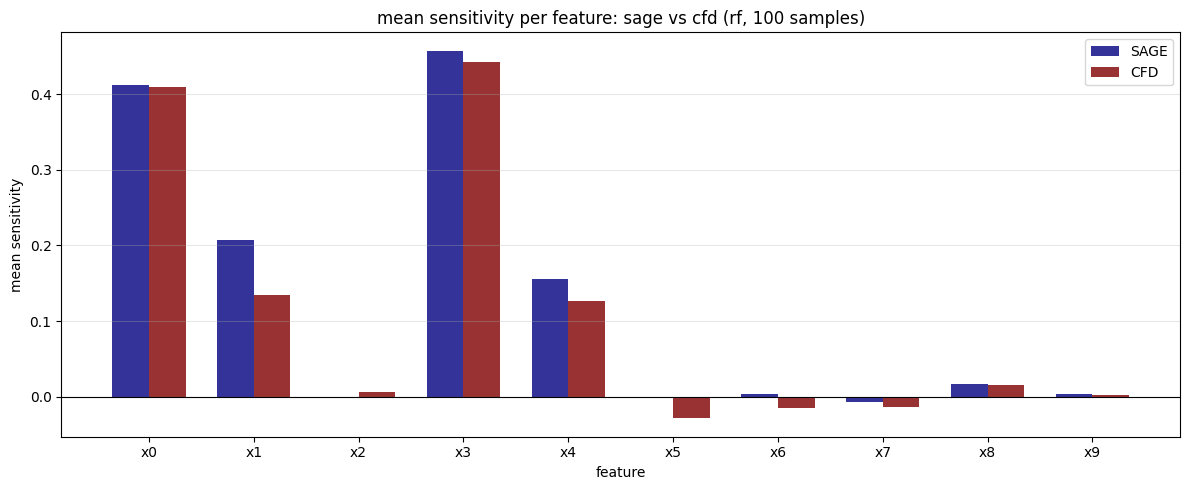

In [64]:
mean_sage = results_df.groupby("feature")["sage"].mean().reindex(feature_names)
mean_cfd = results_df.groupby("feature")["cfd"].mean().reindex(feature_names)

x = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, mean_sage, width, label="SAGE", color="navy", alpha=0.8)
ax.bar(x + width/2, mean_cfd, width, label="CFD", color="maroon", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(feature_names)
ax.set_xlabel("feature")
ax.set_ylabel("mean sensitivity")
ax.set_title("mean sensitivity per feature: sage vs cfd (rf, 100 samples)")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# tuning epsilon for cfd produces wildly different feature sensitivities, 
# sage is much more stable in that its sensitivities are directly calculated with context from dataset